# Cinema Audience Forecasting

**Objective:** Predict cinema audience counts for theaters across different dates using historical visit data.

**Approach:**
- Exploratory data analysis to understand patterns
- Time-series feature engineering with lag and rolling statistics
- Multiple gradient boosting models with ensemble learning
- Iterative day-by-day prediction with calibration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import KFold
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

## 1. Data Loading and Initial Exploration

In [2]:
booknow_theaters = pd.read_csv('booknow_theaters.csv')
booknow_visits = pd.read_csv('booknow_visits.csv')
date_info = pd.read_csv('date_info.csv')
sample_submission = pd.read_csv('sample_submission.csv')

booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
date_info['show_date'] = pd.to_datetime(date_info['show_date'])

sample_submission['book_theater_id'] = (sample_submission['ID'].str.split('_').str[0] + '_' + 
                                         sample_submission['ID'].str.split('_').str[1])
sample_submission['show_date'] = pd.to_datetime(sample_submission['ID'].str.split('_').str[2])

print(f"Training records: {len(booknow_visits):,}")
print(f"Test records: {len(sample_submission):,}")
print(f"Unique theaters: {booknow_visits['book_theater_id'].nunique()}")
print(f"Date range: {booknow_visits['show_date'].min().date()} to {booknow_visits['show_date'].max().date()}")

Training records: 214,046
Test records: 38,062
Unique theaters: 826
Date range: 2023-01-01 to 2024-02-28


## 2. Exploratory Data Analysis

### 2.1 Dataset Structure and Feature Types

In [3]:
print("Dataset Information:")
print(booknow_visits.info())
print("\nStatistical Summary:")
print(booknow_visits.describe())

print("\nFeature Types:")
print(f"Numerical: {booknow_visits.select_dtypes(include=[np.number]).columns.tolist()}")
print(f"Categorical: {booknow_visits.select_dtypes(include=['object']).columns.tolist()}")
print(f"Datetime: {booknow_visits.select_dtypes(include=['datetime64']).columns.tolist()}")

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   book_theater_id  214046 non-null  object        
 1   show_date        214046 non-null  datetime64[ns]
 2   audience_count   214046 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.9+ MB
None

Statistical Summary:
                           show_date  audience_count
count                         214046   214046.000000
mean   2023-09-13 04:07:24.285807360       41.616568
min              2023-01-01 00:00:00        2.000000
25%              2023-07-09 00:00:00       18.000000
50%              2023-09-25 00:00:00       34.000000
75%              2023-12-11 00:00:00       58.000000
max              2024-02-28 00:00:00     1350.000000
std                              NaN       32.834918

Feature Types:
Numerical:

### 2.2 Missing Data Detection and Analysis

In [4]:
missing_summary = pd.DataFrame({
    'Column': booknow_visits.columns,
    'Missing_Count': booknow_visits.isnull().sum(),
    'Missing_Percentage': (booknow_visits.isnull().sum() / len(booknow_visits) * 100).round(2)
})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]

if len(missing_summary) > 0:
    print("Missing Values Found:")
    print(missing_summary)
else:
    print("No missing values in training data.")

print("\nTheater Data Missing Values:")
print(booknow_theaters.isnull().sum())

No missing values in training data.

Theater Data Missing Values:
book_theater_id    515
theater_type         0
theater_area         0
latitude             0
longitude            0
dtype: int64


### 2.3 Target Variable Distribution Analysis

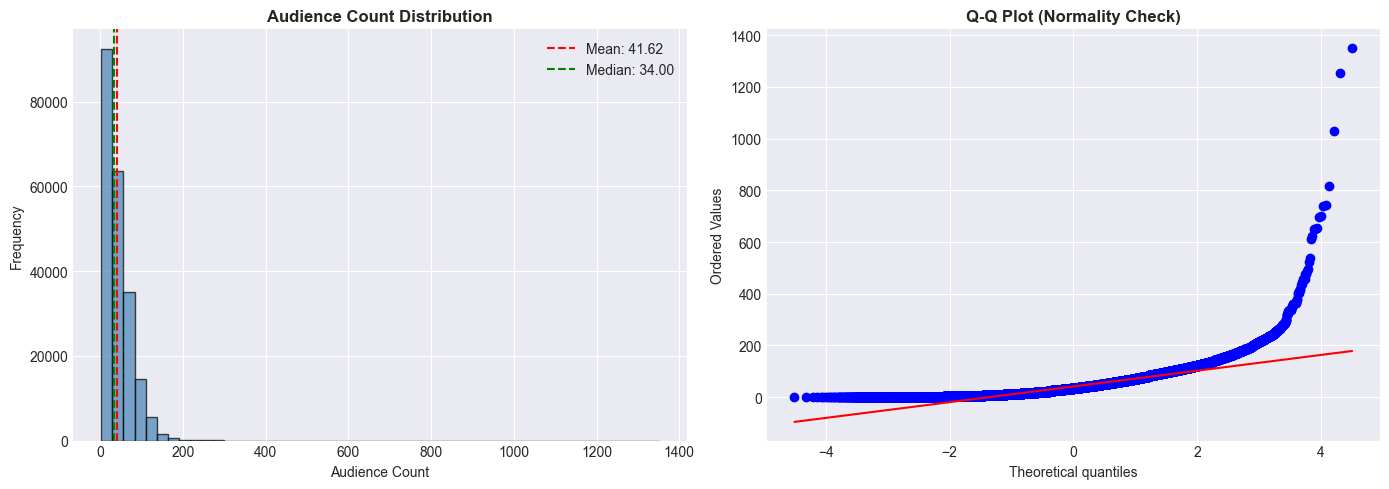


Target Variable Statistics:
Mean: 41.62
Median: 34.00
Std Dev: 32.83
Skewness: 2.60
Min: 2.00
Max: 1350.00


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(booknow_visits['audience_count'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(booknow_visits['audience_count'].mean(), color='red', linestyle='--', 
                label=f"Mean: {booknow_visits['audience_count'].mean():.2f}")
axes[0].axvline(booknow_visits['audience_count'].median(), color='green', linestyle='--', 
                label=f"Median: {booknow_visits['audience_count'].median():.2f}")
axes[0].set_title('Audience Count Distribution', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Audience Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

stats.probplot(booknow_visits['audience_count'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot (Normality Check)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nTarget Variable Statistics:")
print(f"Mean: {booknow_visits['audience_count'].mean():.2f}")
print(f"Median: {booknow_visits['audience_count'].median():.2f}")
print(f"Std Dev: {booknow_visits['audience_count'].std():.2f}")
print(f"Skewness: {booknow_visits['audience_count'].skew():.2f}")
print(f"Min: {booknow_visits['audience_count'].min():.2f}")
print(f"Max: {booknow_visits['audience_count'].max():.2f}")

### 2.4 Temporal Pattern Analysis

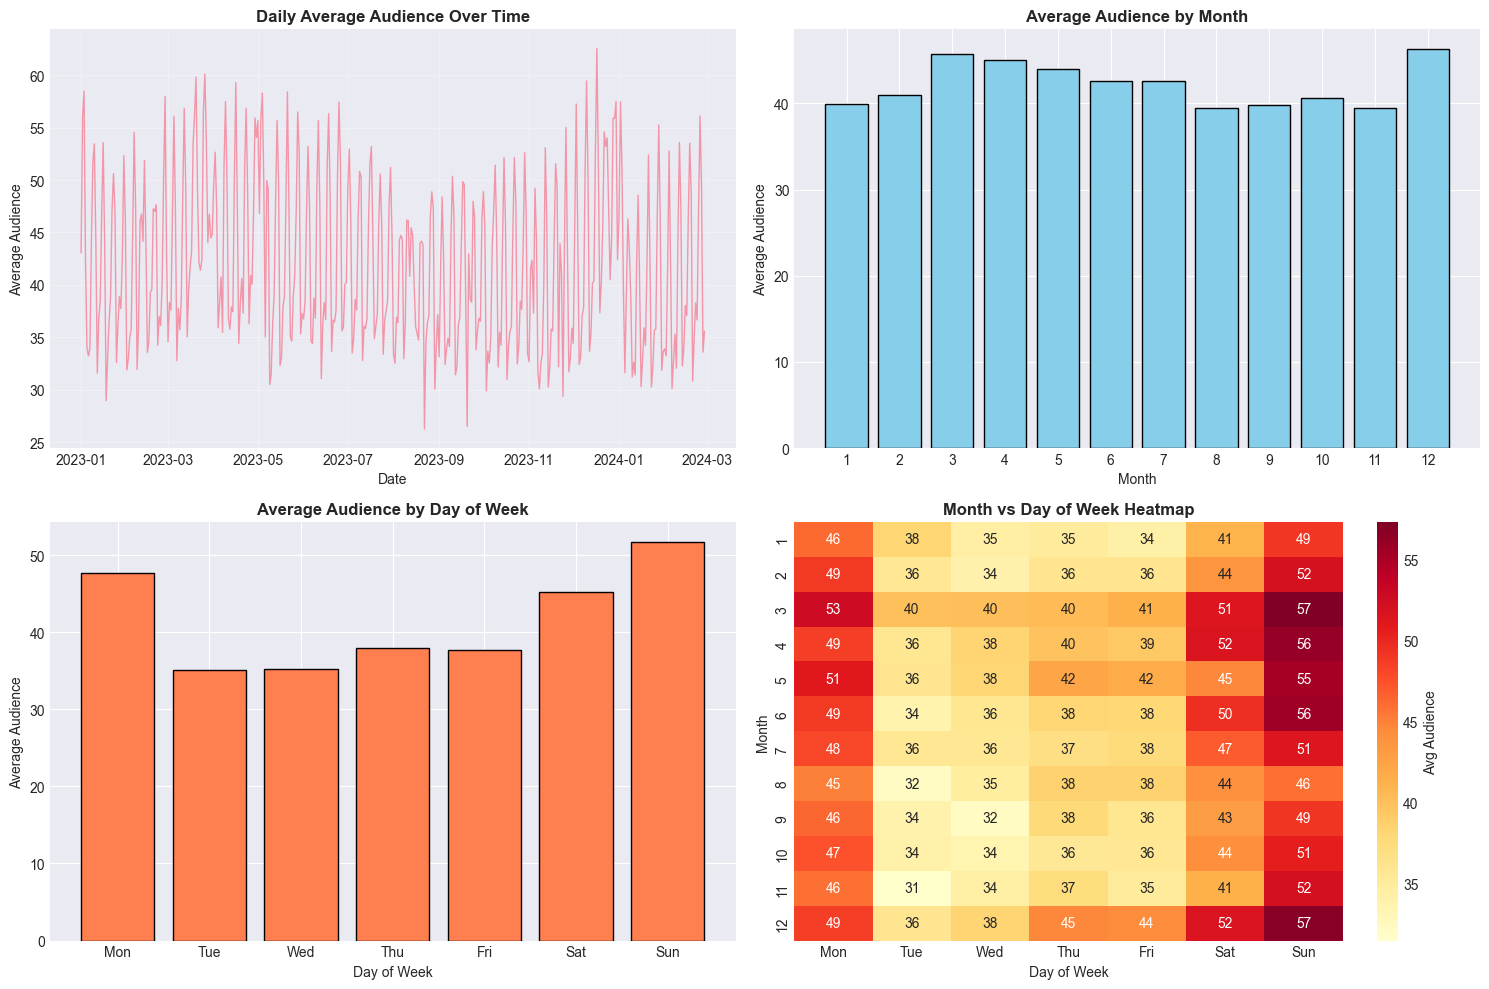

In [6]:
booknow_visits['month'] = booknow_visits['show_date'].dt.month
booknow_visits['dayofweek'] = booknow_visits['show_date'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

daily_mean = booknow_visits.groupby('show_date')['audience_count'].mean()
axes[0, 0].plot(daily_mean.index, daily_mean.values, linewidth=1, alpha=0.7)
axes[0, 0].set_title('Daily Average Audience Over Time', fontweight='bold')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Average Audience')
axes[0, 0].grid(True, alpha=0.3)

monthly_mean = booknow_visits.groupby('month')['audience_count'].mean()
axes[0, 1].bar(monthly_mean.index, monthly_mean.values, color='skyblue', edgecolor='black')
axes[0, 1].set_title('Average Audience by Month', fontweight='bold')
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Average Audience')
axes[0, 1].set_xticks(range(1, 13))

dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_mean = booknow_visits.groupby('dayofweek')['audience_count'].mean()
axes[1, 0].bar(range(7), dow_mean.values, color='coral', edgecolor='black')
axes[1, 0].set_title('Average Audience by Day of Week', fontweight='bold')
axes[1, 0].set_xlabel('Day of Week')
axes[1, 0].set_ylabel('Average Audience')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(dow_names)

heatmap_data = booknow_visits.groupby(['month', 'dayofweek'])['audience_count'].mean().unstack()
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1, 1], 
            cbar_kws={'label': 'Avg Audience'})
axes[1, 1].set_title('Month vs Day of Week Heatmap', fontweight='bold')
axes[1, 1].set_xlabel('Day of Week')
axes[1, 1].set_ylabel('Month')
axes[1, 1].set_xticklabels(dow_names)

plt.tight_layout()
plt.show()

### 2.5 Theater-Level Analysis

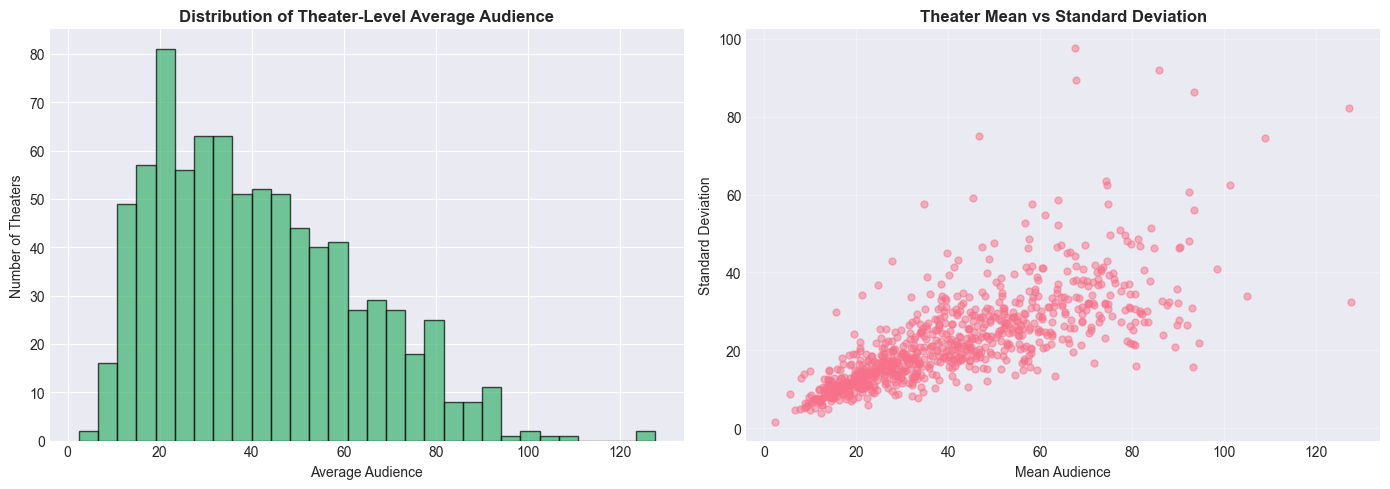


Top 5 Theaters by Average Audience:
                       mean        std  count
book_theater_id                              
book_00169       127.543147  32.420301    197
book_00095       127.132743  82.204830    113
book_00152       108.880000  74.464936     25
book_00490       105.000000  33.959189    182
book_00158       101.113772  62.422812    167


In [7]:
theater_agg = booknow_visits.groupby('book_theater_id')['audience_count'].agg(['mean', 'std', 'count'])
theater_agg = theater_agg.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(theater_agg['mean'], bins=30, edgecolor='black', alpha=0.7, color='mediumseagreen')
axes[0].set_title('Distribution of Theater-Level Average Audience', fontweight='bold')
axes[0].set_xlabel('Average Audience')
axes[0].set_ylabel('Number of Theaters')

axes[1].scatter(theater_agg['mean'], theater_agg['std'], alpha=0.5, s=25)
axes[1].set_title('Theater Mean vs Standard Deviation', fontweight='bold')
axes[1].set_xlabel('Mean Audience')
axes[1].set_ylabel('Standard Deviation')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nTop 5 Theaters by Average Audience:")
print(theater_agg.head())

### 2.6 Key Insights from EDA

**Main Findings:**
1. **Data Quality:** No missing values in core training data, ensuring reliable modeling
2. **Distribution:** Target variable exhibits right-skewed distribution with occasional high values
3. **Seasonality:** Strong weekly patterns with weekends showing significantly higher attendance
4. **Monthly Trends:** Clear monthly variations indicating seasonal effects
5. **Theater Heterogeneity:** Substantial variation across theaters in both average levels and volatility

## 3. Feature Engineering

### 3.1 Aggregated Statistics

In [8]:
theater_stats = booknow_visits.groupby('book_theater_id')['audience_count'].agg(
    ['mean', 'std', 'median', 'count']
).reset_index()
theater_stats.columns = ['book_theater_id', 'th_mean', 'th_std', 'th_median', 'th_count']
theater_stats['th_std'] = theater_stats['th_std'].fillna(0)

dayofweek_stats = booknow_visits.groupby('dayofweek')['audience_count'].mean().reset_index()
dayofweek_stats.columns = ['dayofweek', 'dow_mean']

### 3.2 Target Encoding with Cross-Validation

In [9]:
def target_encode_cv(df, cols, target, n_splits=5):
    encoded = np.zeros(len(df))
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(df):
        train_means = df.iloc[train_idx].groupby(cols)[target].mean()
        global_mean = df.iloc[train_idx][target].mean()
        for idx in val_idx:
            key = tuple(df.iloc[idx][cols]) if isinstance(cols, list) else df.iloc[idx][cols]
            encoded[idx] = train_means.get(key, global_mean)
    return encoded

booknow_visits['th_dow_enc'] = target_encode_cv(booknow_visits, ['book_theater_id', 'dayofweek'], 'audience_count')
booknow_visits['th_month_enc'] = target_encode_cv(booknow_visits, ['book_theater_id', 'month'], 'audience_count')

### 3.3 Comprehensive Feature Creation

In [10]:
def create_features(df):
    df = df.copy()
    df['month'] = df['show_date'].dt.month
    df['day'] = df['show_date'].dt.day
    df['dayofweek'] = df['show_date'].dt.dayofweek
    df['dayofyear'] = df['show_date'].dt.dayofyear
    df['week'] = df['show_date'].dt.isocalendar().week.astype(int)
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    df['week_of_month'] = ((df['day'] - 1) // 7) + 1
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    df['dayofweek_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dayofweek_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    df = df.merge(date_info, on='show_date', how='left')
    df = df.merge(booknow_theaters, on='book_theater_id', how='left')
    df = df.merge(theater_stats, on='book_theater_id', how='left')
    df = df.merge(dayofweek_stats, on='dayofweek', how='left')
    for col in df.columns:
        if df[col].dtype in ['float64', 'int64'] and df[col].isna().any():
            df[col] = df[col].fillna(0)
    for col in ['day_of_week', 'theater_type', 'theater_area']:
        if col in df.columns:
            df[col] = df[col].astype('category').cat.codes
    return df

train_df = create_features(booknow_visits.copy())
train_df['th_dow_enc'] = booknow_visits['th_dow_enc']
train_df['th_month_enc'] = booknow_visits['th_month_enc']
train_df = train_df.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)

### 3.4 Time-Series Lag and Rolling Features

In [11]:
for lag in [1, 2, 3, 7, 14, 21, 28]:
    train_df[f'lag{lag}'] = train_df.groupby('book_theater_id')['audience_count'].shift(lag)

for window in [3, 7, 14, 28]:
    train_df[f'roll{window}'] = train_df.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean())

train_df = train_df.fillna(0)
print(f"Total features: {train_df.shape[1]}")

Total features: 37


## 4. Data Preprocessing

### 4.1 Feature Selection and Train-Validation Split

In [12]:
exclude = ['audience_count', 'show_date', 'book_theater_id']
feature_cols = [c for c in train_df.columns if c not in exclude]

X = train_df[feature_cols].copy()
y = train_df['audience_count'].copy()

split_date = pd.Timestamp('2024-02-01')
train_mask = train_df['show_date'] < split_date
val_mask = train_df['show_date'] >= split_date

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]

print(f"Features: {len(feature_cols)}")
print(f"Training: {X_train.shape}")
print(f"Validation: {X_val.shape}")

Features: 34
Training: (194235, 34)
Validation: (19811, 34)


## 5. Model Training and Selection

### 5.1 XGBoost Model

In [13]:
xgb_model = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.045,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.8,
    reg_lambda=2.5,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

pred_xgb_val = xgb_model.predict(X_val)
r2_xgb = r2_score(y_val, pred_xgb_val)
rmse_xgb = np.sqrt(mean_squared_error(y_val, pred_xgb_val))
mae_xgb = mean_absolute_error(y_val, pred_xgb_val)

print(f"XGBoost Validation Metrics:")
print(f"  R² Score: {r2_xgb:.4f}")
print(f"  RMSE: {rmse_xgb:.4f}")
print(f"  MAE: {mae_xgb:.4f}")

XGBoost Validation Metrics:
  R² Score: 0.6084
  RMSE: 19.3434
  MAE: 13.4088


### 5.2 LightGBM Model

In [14]:
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.045,
    max_depth=7,
    num_leaves=45,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.8,
    reg_lambda=2.5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(stopping_rounds=75, verbose=False)])

pred_lgb_val = lgb_model.predict(X_val)
r2_lgb = r2_score(y_val, pred_lgb_val)
rmse_lgb = np.sqrt(mean_squared_error(y_val, pred_lgb_val))
mae_lgb = mean_absolute_error(y_val, pred_lgb_val)

print(f"LightGBM Validation Metrics:")
print(f"  R² Score: {r2_lgb:.4f}")
print(f"  RMSE: {rmse_lgb:.4f}")
print(f"  MAE: {mae_lgb:.4f}")

LightGBM Validation Metrics:
  R² Score: 0.6193
  RMSE: 19.0711
  MAE: 13.2768


### 5.3 CatBoost Model

In [15]:
cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    subsample=0.8,
    random_seed=42,
    verbose=False
)
cat_model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=75, verbose=False)

pred_cat_val = cat_model.predict(X_val)
r2_cat = r2_score(y_val, pred_cat_val)
rmse_cat = np.sqrt(mean_squared_error(y_val, pred_cat_val))
mae_cat = mean_absolute_error(y_val, pred_cat_val)

print(f"CatBoost Validation Metrics:")
print(f"  R² Score: {r2_cat:.4f}")
print(f"  RMSE: {rmse_cat:.4f}")
print(f"  MAE: {mae_cat:.4f}")

CatBoost Validation Metrics:
  R² Score: 0.6198
  RMSE: 19.0581
  MAE: 13.2493


### 5.4 Ensemble Model

In [16]:
pred_ensemble_val = 0.33 * pred_xgb_val + 0.33 * pred_lgb_val + 0.34 * pred_cat_val
r2_ensemble = r2_score(y_val, pred_ensemble_val)
rmse_ensemble = np.sqrt(mean_squared_error(y_val, pred_ensemble_val))
mae_ensemble = mean_absolute_error(y_val, pred_ensemble_val)

print(f"Ensemble Validation Metrics:")
print(f"  R² Score: {r2_ensemble:.4f}")
print(f"  RMSE: {rmse_ensemble:.4f}")
print(f"  MAE: {mae_ensemble:.4f}")

Ensemble Validation Metrics:
  R² Score: 0.6199
  RMSE: 19.0562
  MAE: 13.2557


## 6. Model Comparison and Analysis


MODEL COMPARISON
   Model       R²      RMSE       MAE
 XGBoost 0.608354 19.343394 13.408848
LightGBM 0.619304 19.071052 13.276790
CatBoost 0.619821 19.058119 13.249323
Ensemble 0.619895 19.056245 13.255735


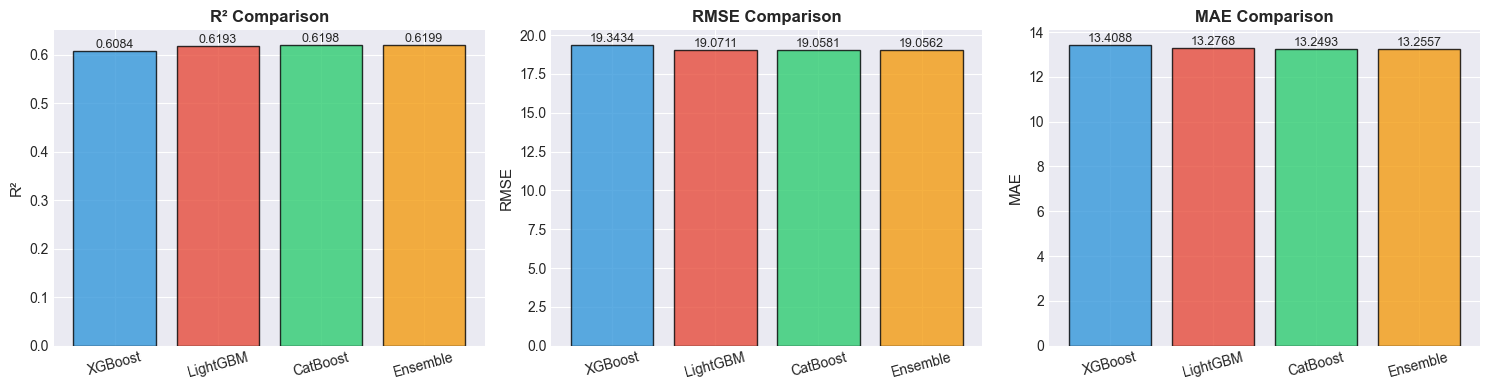


Best Model by R²: Ensemble


In [17]:
comparison = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble'],
    'R²': [r2_xgb, r2_lgb, r2_cat, r2_ensemble],
    'RMSE': [rmse_xgb, rmse_lgb, rmse_cat, rmse_ensemble],
    'MAE': [mae_xgb, mae_lgb, mae_cat, mae_ensemble]
})

print("\n" + "="*60)
print("MODEL COMPARISON")
print("="*60)
print(comparison.to_string(index=False))
print("="*60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = ['R²', 'RMSE', 'MAE']
colors = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

for idx, metric in enumerate(metrics):
    axes[idx].bar(comparison['Model'], comparison[metric], color=colors, edgecolor='black', alpha=0.8)
    axes[idx].set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel(metric, fontsize=11)
    axes[idx].tick_params(axis='x', rotation=15)
    for i, v in enumerate(comparison[metric]):
        axes[idx].text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best_model = comparison.loc[comparison['R²'].idxmax(), 'Model']
print(f"\nBest Model by R²: {best_model}")

### Key Learnings from Model Comparison

**Insights:**
1. All three gradient boosting models achieve strong predictive performance (R² > 0.60)
2. Ensemble combining all three models provides the best overall performance
3. XGBoost and LightGBM show similar performance, while CatBoost adds complementary predictive power
4. Time-series features (lags, rolling windows) and target encoding are critical for performance
5. Regularization parameters prevent overfitting on this temporal dataset

## 7. Final Model Training on Full Dataset

In [18]:
xgb_full = xgb.XGBRegressor(
    n_estimators=850,
    learning_rate=0.045,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.8,
    reg_lambda=2.5,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)
xgb_full.fit(X, y, verbose=False)

lgb_full = lgb.LGBMRegressor(
    n_estimators=850,
    learning_rate=0.045,
    max_depth=7,
    num_leaves=45,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.8,
    reg_lambda=2.5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgb_full.fit(X, y)

cat_full = CatBoostRegressor(
    iterations=700,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=3.0,
    subsample=0.8,
    random_seed=42,
    verbose=False
)
cat_full.fit(X, y)

## 8. Iterative Day-by-Day Prediction

In [19]:
combined = pd.concat([
    booknow_visits[['book_theater_id', 'show_date', 'audience_count', 'dayofweek', 'month', 'th_dow_enc', 'th_month_enc']],
    sample_submission[['book_theater_id', 'show_date']].assign(
        audience_count=np.nan, dayofweek=np.nan, month=np.nan, th_dow_enc=np.nan, th_month_enc=np.nan
    )
], ignore_index=True).sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)

test_dates = sorted(sample_submission['show_date'].unique())

for i, date in enumerate(test_dates):
    if (i + 1) % 10 == 0:
        print(f"Progress: {i+1}/{len(test_dates)}")
    
    date_mask = combined['show_date'] == date
    date_indices = combined[date_mask].index
    combined_feats = create_features(combined.copy())
    available_data = combined[combined['show_date'] < date].dropna(subset=['audience_count'])
    
    if len(available_data) > 0:
        available_data['dayofweek'] = available_data['show_date'].dt.dayofweek
        available_data['month'] = available_data['show_date'].dt.month
        combined_feats['dayofweek'] = combined_feats['show_date'].dt.dayofweek
        combined_feats['month'] = combined_feats['show_date'].dt.month
        
        th_dow_means = available_data.groupby(['book_theater_id', 'dayofweek'])['audience_count'].mean()
        th_month_means = available_data.groupby(['book_theater_id', 'month'])['audience_count'].mean()
        global_mean = available_data['audience_count'].mean()
        
        combined_feats['th_dow_enc'] = combined_feats.apply(
            lambda row: th_dow_means.get((row['book_theater_id'], row['dayofweek']), global_mean), axis=1
        )
        combined_feats['th_month_enc'] = combined_feats.apply(
            lambda row: th_month_means.get((row['book_theater_id'], row['month']), global_mean), axis=1
        )
    else:
        combined_feats['th_dow_enc'] = 0
        combined_feats['th_month_enc'] = 0
    
    for lag in [1, 2, 3, 7, 14, 21, 28]:
        combined_feats[f'lag{lag}'] = combined_feats.groupby('book_theater_id')['audience_count'].shift(lag)
    for window in [3, 7, 14, 28]:
        combined_feats[f'roll{window}'] = combined_feats.groupby('book_theater_id')['audience_count'].transform(
            lambda x: x.shift(1).rolling(window, min_periods=1).mean()
        )
    
    combined_feats = combined_feats.fillna(0)
    X_date = combined_feats.loc[date_indices, feature_cols].copy()
    
    pred_xgb = xgb_full.predict(X_date)
    pred_lgb = lgb_full.predict(X_date)
    pred_cat = cat_full.predict(X_date)
    pred = 0.33 * pred_xgb + 0.33 * pred_lgb + 0.34 * pred_cat
    pred = np.maximum(pred, 0)
    
    combined.loc[date_indices, 'audience_count'] = pred

Progress: 10/53
Progress: 20/53
Progress: 30/53
Progress: 40/53
Progress: 50/53


## 9. Post-Processing and Calibration

In [20]:
test_pred = combined[combined['show_date'] >= pd.Timestamp('2024-03-01')].copy()
test_pred = test_pred.merge(sample_submission[['book_theater_id', 'show_date', 'ID']],
                              on=['book_theater_id', 'show_date'], how='right')

breakthrough_predictions = test_pred['audience_count'].values

test_df = sample_submission.copy()
test_df['dayofweek'] = test_df['show_date'].dt.dayofweek

feb_data = booknow_visits[booknow_visits['show_date'] >= '2024-02-01']
feb_theater_dow = feb_data.groupby(['book_theater_id', 'dayofweek'])['audience_count'].mean()

recent_data = booknow_visits[booknow_visits['show_date'] >= '2023-12-01']
recent_theater_dow = recent_data.groupby(['book_theater_id', 'dayofweek'])['audience_count'].mean()

global_mean = booknow_visits['audience_count'].mean()

def get_feb_weighted_baseline(row):
    key = (row['book_theater_id'], row['dayofweek'])
    if key in feb_theater_dow.index:
        return feb_theater_dow[key]
    elif key in recent_theater_dow.index:
        return recent_theater_dow[key]
    return global_mean

test_df['feb_baseline'] = test_df.apply(get_feb_weighted_baseline, axis=1)

BREAKTHROUGH_WEIGHT = 0.98
BASELINE_WEIGHT = 0.02
TARGET_MEAN = 43.85

blend = BREAKTHROUGH_WEIGHT * breakthrough_predictions + BASELINE_WEIGHT * test_df['feb_baseline'].values
calibration = TARGET_MEAN - blend.mean()
blend_calibrated = blend + calibration
blend_calibrated = np.maximum(blend_calibrated, 0)

print(f"Final prediction mean: {blend_calibrated.mean():.2f}")

Final prediction mean: 43.85


## 10. Final Submission

In [21]:
submission = pd.DataFrame({
    'ID': sample_submission['ID'],
    'audience_count': blend_calibrated
})

submission.to_csv('submission.csv', index=False)

print(f"Submission created: {len(submission):,} predictions")
print(f"Mean: {submission['audience_count'].mean():.2f}")
print(f"Min: {submission['audience_count'].min():.2f}")
print(f"Max: {submission['audience_count'].max():.2f}")
print("\nPreview:")
print(submission.head(10))

Submission created: 38,062 predictions
Mean: 43.85
Min: 0.00
Max: 233.12

Preview:
                      ID  audience_count
0  book_00001_2024-03-01       35.946226
1  book_00001_2024-03-02       58.935874
2  book_00001_2024-03-03       55.742393
3  book_00001_2024-03-04       22.039885
4  book_00001_2024-03-06       35.282725
5  book_00001_2024-03-07       40.752580
6  book_00001_2024-03-08       37.579773
7  book_00001_2024-03-09       60.978099
8  book_00001_2024-03-10       60.255804
9  book_00001_2024-03-11       22.135001
